

# Spotify EDA Notebook Guide


**Focus Of The EDA**


In this EDA the data that is focused on is the Spotify dataset of my own usage. Trough first statistical data analysis, and then later on the data visualization. Below much more detailed explanation


## 1. Notebook Setup And Data Loading

This section prepares the notebook environment and loads the public Spotify dataset.

- Imports the required libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, and `Path`.
- Sets a readable seaborn plotting theme using a colorblind-friendly palette.
- Defines paths so the notebook can run from either the repo root or the `EDA/` folder.
- Loads:
  - `data_github/spotify_public/spotify_streaming_public.csv`
- Creates the image output folder:
  - `EDA/spotify_images`

Related cells: `1-2`

## 2. Basic Data Inspection

This section checks the structure of the Spotify dataset before visualization.

- Prints sample Spotify rows.
- Prints dataset shape.
- Prints column names.
- Prints dataframe info.
- Prints missing-value counts.

The goal is to confirm what fields are available and whether the public Spotify table is ready for EDA.

Related cells: `3-4`

## 3. Date, Timestamp, And Duration Preparation

This section prepares date/time fields and checks listening duration values.

- Converts `fine_date` into datetime format.
- Parses `fine_time_start` as an ISO timestamp.
- Converts timestamps to Istanbul time.
- Prints the Spotify date range.
- Checks invalid timestamp count after parsing.
- Prints summary statistics for:
  - `ms_played`
  - `minutes_played`
  - `hours_played`

This step matters because later analysis uses both daily dates and hour-of-day behavior.

Related cells: `5-6`

## 4. Daily Spotify Summary Table

This section creates the main daily Spotify table used in the EDA.

- Groups Spotify rows by `fine_date`.
- Creates daily variables:
  - `spotify_daily_hours`
  - `spotify_daily_minutes`
  - `spotify_daily_stream_count`
  - `spotify_daily_unique_tracks`
- Creates a full date range from the first Spotify date to the last Spotify date.
- Merges daily Spotify activity into the full date range.
- Fills inactive dates with zero activity.
- Creates `spotify_active_day`.
- Prints descriptive statistics for daily Spotify variables.
- Prints active-day counts.

Related cells: `7-8`

## 5. Daily And Monthly Listening Trends

This section visualizes Spotify listening over time.

- Plots daily Spotify listening hours.
- Aggregates Spotify activity to monthly totals.
- Plots monthly Spotify listening hours.
- Annotates the peak month in the monthly listening plot.

Plot outputs:
- `spotify_daily_listening_hours.png`
- `spotify_monthly_listening_hours.png`

Related cells: `9-12`

## 6. Daily Listening Distribution

This section checks how daily Spotify listening hours are distributed.

- Plots a histogram with KDE for `spotify_daily_hours`.

This helps show that daily listening is not normally distributed and has high-activity outliers.

Plot output:
- `spotify_daily_hours_distribution.png`

Related cell: `13`

## 7. Top Artist And Track Analysis

This section looks at the most repeated Spotify content.

For artists:
- Groups rows by `artist_name`.
- Sums total `hours_played`.
- Selects the top 15 artists.
- Plots them as a horizontal bar chart.

For tracks:
- Combines `track_name` and `artist_name` into `track_artist`.
- Groups by `track_artist`.
- Sums total `hours_played`.
- Selects the top 15 tracks.
- Plots them as a horizontal bar chart.

These plots are useful for understanding listening concentration, but the main hypothesis variables still use daily listening hours and stream counts.

Plot outputs:
- `spotify_top_15_artists_by_hours.png`
- `spotify_top_15_tracks_by_hours.png`

Related cells: `14-17`

## 8. Streams, Hours, And Weekday Patterns

This section checks richer daily listening patterns.

- Plots daily stream count vs daily listening hours.
- Uses point size to represent daily unique tracks.
- Creates weekday labels from `fine_date`.
- Plots Spotify daily listening hours by weekday using a boxplot.

Plot outputs:
- `spotify_daily_streams_vs_hours.png`
- `spotify_daily_hours_by_weekday_boxplot.png`

Related cells: `18-19`

## 9. Hour-Of-Day Listening Pattern

This section checks when Spotify listening happens during the day.

- Extracts `hour_istanbul` from the parsed Istanbul timestamp.
- Groups Spotify rows by hour.
- Computes:
  - total listening hours by hour
  - stream count by hour
- Plots total listening hours by hour of day.

Plot output:
- `spotify_listening_hours_by_hour.png`

Related cells: `20-21`

## 10. After-9:30 PM Listening

This section prepares late-evening Spotify variables for later hypothesis testing.

- Converts each timestamp into `minute_of_day`.
- Flags listening after 21:30 or before 05:00 as `is_after_2130`.
- Groups after-21:30 records by date.
- Creates daily after-21:30 listening variables.
- Merges those variables into the daily Spotify table.
- Fills missing late-evening values with zero.
- Plots daily Spotify listening hours after 9:30 PM.

Plot output:
- `spotify_daily_after_2130_hours.png`

Related cells: `22-23`

## 11. Overview Panel

This section creates one compact multi-panel summary figure.

The 2x2 overview panel includes:
- Daily Spotify listening hours over time
- Distribution of daily listening hours
- Daily stream count vs daily listening hours
- Listening hours by hour of day

Plot output:
- `spotify_eda_overview_panel.png`

Related cell: `24`


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# Settin a themee for the plots. So it would be easier for later on in terms of aesthetics and consistency.
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")

# Path handling works from repo root or from inside EDA/.

# Sometimes the data is in the parent directory, sometimes it's in the same directory. So we check for both cases and set the path accordingly.
if Path("data_github/spotify_public/spotify_streaming_public.csv").exists():
    spotify_data_path = Path("data_github/spotify_public/spotify_streaming_public.csv")
    spotify_image_dir = Path("EDA/spotify_images")
else:
    spotify_data_path = Path("../data_github/spotify_public/spotify_streaming_public.csv")
    spotify_image_dir = Path("spotify_images")

spotify_image_dir.mkdir(parents=True, exist_ok=True)

spotify_data = pd.read_csv(spotify_data_path)


In [18]:
print("Spotify data sample:")
print(spotify_data.head())

print("\nShape:")
print(spotify_data.shape)

print("\nColumns:")
print(spotify_data.columns.tolist())


Spotify data sample:
  fine_platform                fine_table         fine_record_id  \
0       spotify  spotify_streaming_public  spotify_stream_000001   
1       spotify  spotify_streaming_public  spotify_stream_000002   
2       spotify  spotify_streaming_public  spotify_stream_000003   
3       spotify  spotify_streaming_public  spotify_stream_000004   
4       spotify  spotify_streaming_public  spotify_stream_000005   

     fine_account fine_source_file              fine_time_start  \
0  account_000001    source_000001  2019-07-27T07:57:41.217000Z   
1  account_000001    source_000001  2019-07-27T07:57:44.627000Z   
2  account_000001    source_000001  2019-07-27T08:03:19.600000Z   
3  account_000001    source_000001  2019-07-27T08:09:55.134000Z   
4  account_000001    source_000001  2019-07-27T08:13:41.614000Z   

          fine_time_end fine_time_granularity   fine_date  track_ref_id  \
0  2019-07-27T07:57:46Z             timestamp  2019-07-27  track_000001   
1  2019-07-27T08:

In [19]:
print("Spotify Data Info:")
print(spotify_data.info())

print("\nMissing values:")
print(spotify_data.isna().sum())

Spotify Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178202 entries, 0 to 178201
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   fine_platform          178202 non-null  object 
 1   fine_table             178202 non-null  object 
 2   fine_record_id         178202 non-null  object 
 3   fine_account           178202 non-null  object 
 4   fine_source_file       178202 non-null  object 
 5   fine_time_start        178202 non-null  object 
 6   fine_time_end          178202 non-null  object 
 7   fine_time_granularity  178202 non-null  object 
 8   fine_date              178202 non-null  object 
 9   track_ref_id           178202 non-null  object 
 10  track_name             178202 non-null  object 
 11  artist_name            178202 non-null  object 
 12  album_name             178202 non-null  object 
 13  ms_played              178202 non-null  int64  
 14  minutes_played   

In [20]:
# Parsing dates and timestamps.
spotify_data["fine_date"] = pd.to_datetime(spotify_data["fine_date"])

# Spotify timestamps are ISO strings, but some have fractional seconds and some do not.
# format="ISO8601" handles both formats correctly.
spotify_data["fine_time_start_dt"] = pd.to_datetime(spotify_data["fine_time_start"],errors="coerce",utc=True,format="ISO8601").dt.tz_convert("Europe/Istanbul")

print("Date range:")
print(spotify_data["fine_date"].min(), "to", spotify_data["fine_date"].max())


# In first runs I had some issues with parsing the timestamps, so I want to check how many invalid timestamps we have after parsing. This can help us understand if the issue is widespread or limited to a few rows.
# Due to existing of fractional seconds in some timestamps, some of them might have been parsed as NaT. So we check for that and count how many invalid timestamps we have after parsing.
print("\nInvalid timestamps after fixed parsing:")
print(spotify_data["fine_time_start_dt"].isna().sum())


Date range:
2019-07-27 00:00:00 to 2026-03-14 00:00:00

Invalid timestamps after fixed parsing:
0


In [21]:
# Basic duration summary.
print("Spotify duration summary:")
print(spotify_data[["ms_played", "minutes_played", "hours_played"]].describe())


Spotify duration summary:
          ms_played  minutes_played   hours_played
count  1.782020e+05   178202.000000  178202.000000
mean   7.199684e+04        1.199947       0.019999
std    1.004838e+05        1.674729       0.027912
min    0.000000e+00        0.000000       0.000000
25%    9.400000e+02        0.015667       0.000261
50%    4.354500e+03        0.072575       0.001210
75%    1.650712e+05        2.751188       0.045853
max    1.624417e+06       27.073617       0.451227


In [22]:
# Daily Spotify listening.
spotify_daily = (spotify_data.groupby("fine_date").agg
(spotify_daily_hours=("hours_played", "sum")
,spotify_daily_minutes=("minutes_played", "sum")
,spotify_daily_stream_count=("fine_record_id", "count")
,spotify_daily_unique_tracks=("track_ref_id", "nunique")).reset_index()
)

# Filling inactive dates with zero activity.
all_dates = pd.DataFrame({"fine_date": pd.date_range(start=spotify_data["fine_date"].min(),end=spotify_data["fine_date"].max(),freq="D")})

spotify_daily = all_dates.merge(spotify_daily, on="fine_date", how="left")

for column in [
    "spotify_daily_hours",
    "spotify_daily_minutes",
    "spotify_daily_stream_count",
    "spotify_daily_unique_tracks"
]:
    spotify_daily[column] = spotify_daily[column].fillna(0)

spotify_daily["spotify_daily_stream_count"] = spotify_daily["spotify_daily_stream_count"].astype(int)
spotify_daily["spotify_daily_unique_tracks"] = spotify_daily["spotify_daily_unique_tracks"].astype(int)
spotify_daily["spotify_active_day"] = spotify_daily["spotify_daily_stream_count"] > 0

print("Spotify daily sample:")
print(spotify_daily.head())


Spotify daily sample:
   fine_date  spotify_daily_hours  spotify_daily_minutes  \
0 2019-07-27             0.314114              18.846799   
1 2019-07-28             0.861175              51.670568   
2 2019-07-29             1.745592             104.735502   
3 2019-07-30             0.530142              31.808471   
4 2019-07-31             0.653267              39.196066   

   spotify_daily_stream_count  spotify_daily_unique_tracks  spotify_active_day  
0                           5                            4                True  
1                          20                           18                True  
2                          34                           13                True  
3                          20                           15                True  
4                          13                           10                True  


In [23]:
print("Spotify daily summary:")
print(spotify_daily[[
    "spotify_daily_hours",
    "spotify_daily_stream_count",
    "spotify_daily_unique_tracks"
]].describe())

print("\nSpotify active day counts:")
print(spotify_daily["spotify_active_day"].value_counts())


Spotify daily summary:
       spotify_daily_hours  spotify_daily_stream_count  \
count          2423.000000                 2423.000000   
mean              1.470855                   73.546017   
std               1.491048                   89.820172   
min               0.000000                    0.000000   
25%               0.254698                    9.000000   
50%               1.118269                   46.000000   
75%               2.156189                  102.000000   
max               9.310045                  768.000000   

       spotify_daily_unique_tracks  
count                  2423.000000  
mean                     57.673132  
std                      68.811838  
min                       0.000000  
25%                       7.000000  
50%                      36.000000  
75%                      80.000000  
max                     565.000000  

Spotify active day counts:
spotify_active_day
True     2132
False     291
Name: count, dtype: int64


****VISUALIZATIONS****

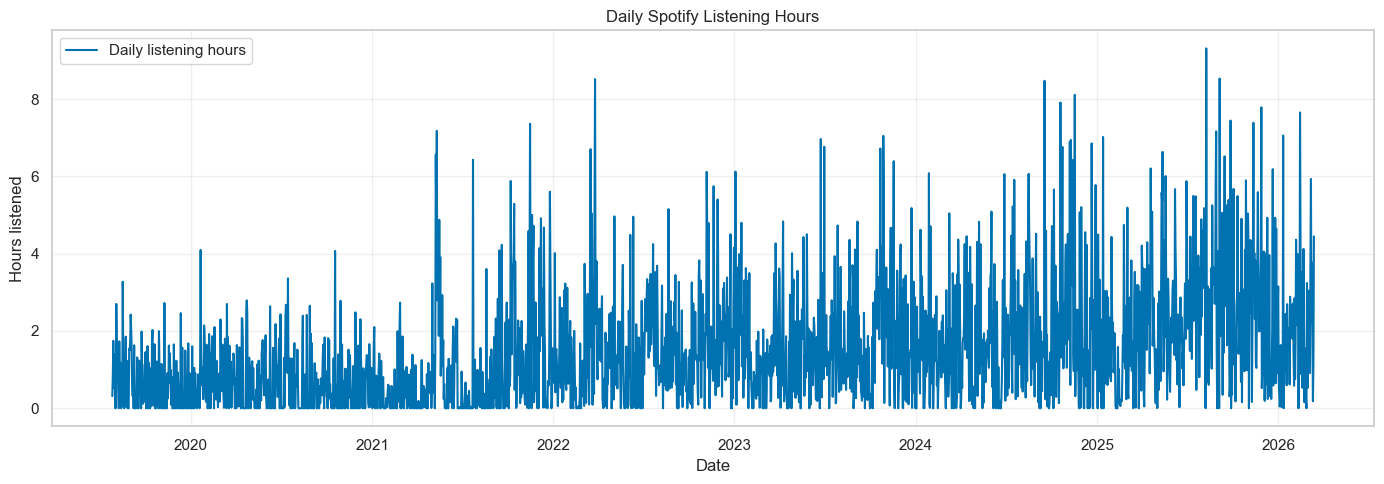

In [ ]:
# Daily listening trend.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    spotify_daily["fine_date"],
    spotify_daily["spotify_daily_hours"],
    color="#0072B2",
    linewidth=1.5,
    label="Daily listening hours"
)

ax.set_title("Daily Spotify Listening Hours")
ax.set_xlabel("Date")
ax.set_ylabel("Hours listened")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_daily_listening_hours.png", dpi=300)
plt.show()


In [25]:
# Monthly totals make long-term changes easier to read.
spotify_monthly = spotify_daily.copy()
spotify_monthly["month"] = spotify_monthly["fine_date"].dt.to_period("M").dt.to_timestamp()

spotify_monthly = (
    spotify_monthly
    .groupby("month")[[
        "spotify_daily_hours",
        "spotify_daily_stream_count",
        "spotify_daily_unique_tracks"
    ]]
    .sum()
    .reset_index()
)

print("Spotify monthly sample:")
print(spotify_monthly.head())


Spotify monthly sample:
       month  spotify_daily_hours  spotify_daily_stream_count  \
0 2019-07-01             4.104290                          92   
1 2019-08-01            26.459779                         926   
2 2019-09-01            21.956986                         795   
3 2019-10-01            19.987742                        1014   
4 2019-11-01            15.655926                        1048   

   spotify_daily_unique_tracks  
0                           60  
1                          600  
2                          514  
3                          784  
4                          831  


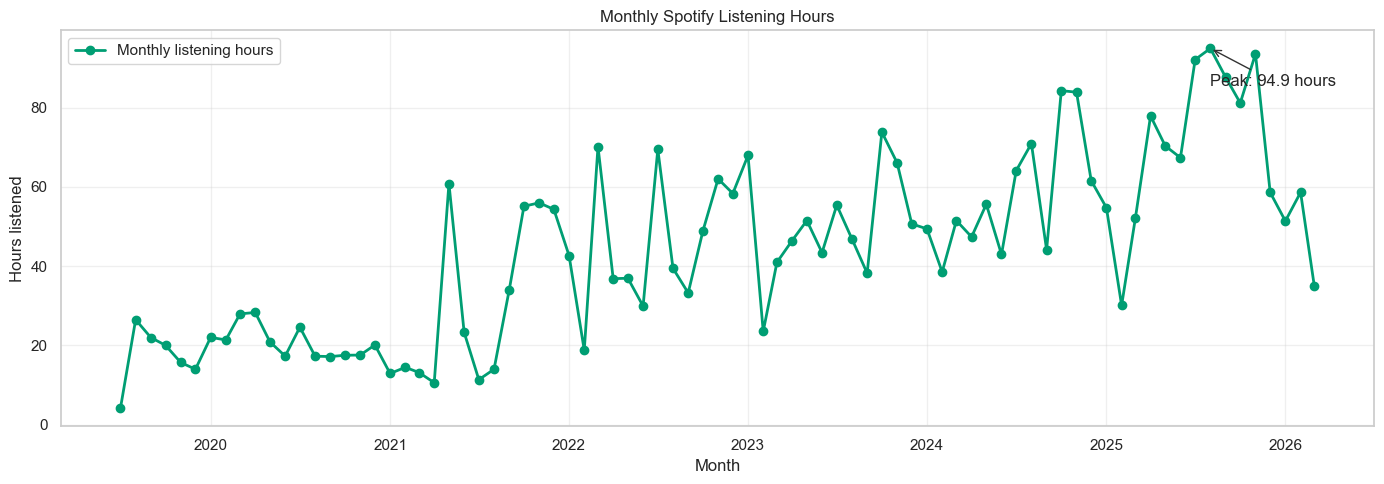

In [ ]:

# Monthlu listenign trend with annotation for the peak month. This can help us understand if there are any seasonal patterns or significant changes in listening behavior over time.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    spotify_monthly["month"],
    spotify_monthly["spotify_daily_hours"],
    color="#009E73",
    marker="o",
    linewidth=2,
    label="Monthly listening hours"
)

max_idx = spotify_monthly["spotify_daily_hours"].idxmax()
ax.annotate(
    f"Peak: {spotify_monthly.loc[max_idx, 'spotify_daily_hours']:.1f} hours",
    xy=(spotify_monthly.loc[max_idx, "month"], spotify_monthly.loc[max_idx, "spotify_daily_hours"]),
    xytext=(spotify_monthly.loc[max_idx, "month"], spotify_monthly["spotify_daily_hours"].max() * 0.9),
    arrowprops=dict(arrowstyle="->", color="#333333")
)

ax.set_title("Monthly Spotify Listening Hours")
ax.set_xlabel("Month")
ax.set_ylabel("Hours listened")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_monthly_listening_hours.png", dpi=300)
plt.show()


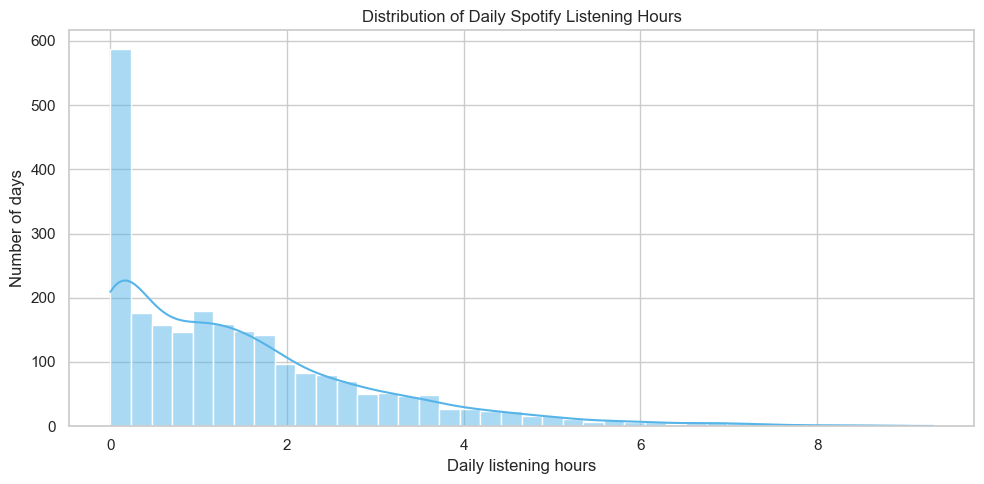

In [27]:
# Distribution of daily listening hours.
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=spotify_daily,
    x="spotify_daily_hours",
    bins=40,
    kde=True,
    ax=ax,
    color="#56B4E9"
)

ax.set_title("Distribution of Daily Spotify Listening Hours")
ax.set_xlabel("Daily listening hours")
ax.set_ylabel("Number of days")
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_daily_hours_distribution.png", dpi=300)
plt.show()


In [28]:
# Top artists by total listening time.
spotify_top_artists = (
    spotify_data
    .groupby("artist_name")["hours_played"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

print("Top Spotify artists by listening hours:")
print(spotify_top_artists)


Top Spotify artists by listening hours:
artist_name
Blake Shelton       25.808323
Sertab Erener       25.836418
Sıla                28.593110
Céline Dion         29.759936
Teoman              30.577701
Göksel              31.820517
Dua Lipa            35.807200
The Cranberries     36.206668
Imagine Dragons     37.936072
Murat Dalkılıç      38.691648
Gwen Stefani        45.644901
mor ve ötesi        67.067146
Eminem              68.292452
Robbie Williams     71.801857
Taylor Swift       103.923671
Name: hours_played, dtype: float64


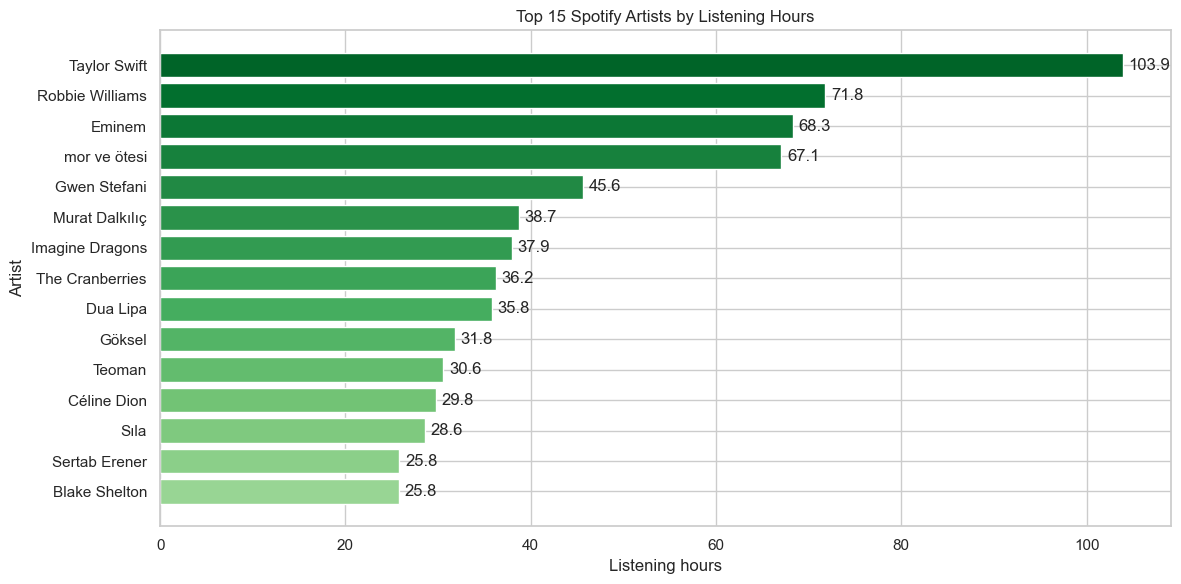

In [ ]:
# Plotting of the top 15 artists by total listening hours. This can help us understand which artists are most listened to and if there are any dominant artists in the listening history.

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(spotify_top_artists.index,spotify_top_artists.values,color=plt.cm.Greens(np.linspace(0.4, 0.9, len(spotify_top_artists))))

ax.set_title("Top 15 Spotify Artists by Listening Hours")
ax.set_xlabel("Listening hours")
ax.set_ylabel("Artist")
ax.bar_label(bars, fmt="%.1f", padding=4)
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_top_15_artists_by_hours.png", dpi=300)
plt.show()


In [38]:
# Top tracks by total listening time.
spotify_top_tracks = (spotify_data.assign(track_artist=spotify_data["track_name"] + " - " + spotify_data["artist_name"])
    .groupby("track_artist")["hours_played"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

print("Top Spotify tracks by listening hours:")
print(spotify_top_tracks)


Top Spotify tracks by listening hours:
track_artist
Him & I (with Halsey) - G-Eazy                   6.790830
Sen Çal Kapımı - Başak Gümülcinelioğlu           6.821546
Korkma - mor ve ötesi                            6.840361
Saygımdan - Bengü                                6.864867
Un nuovo bacio - Gigi D'Alessio                  7.099958
Night Changes - One Direction                    7.314765
Is This Love - Whitesnake                        7.535621
Susamam - Şanışer                                7.861303
It's All Coming Back to Me Now - Céline Dion     8.022803
Neyleyim İstanbulu - Murat Dalkılıç              8.415549
Don't You (Forget About Me) - Simple Minds       8.732910
Locked Away (feat. Adam Levine) - R. City        9.119807
Dreams - The Cranberries                         9.528264
Animal Instinct - The Cranberries               10.087235
This I Love - Guns N' Roses                     10.129877
Name: hours_played, dtype: float64


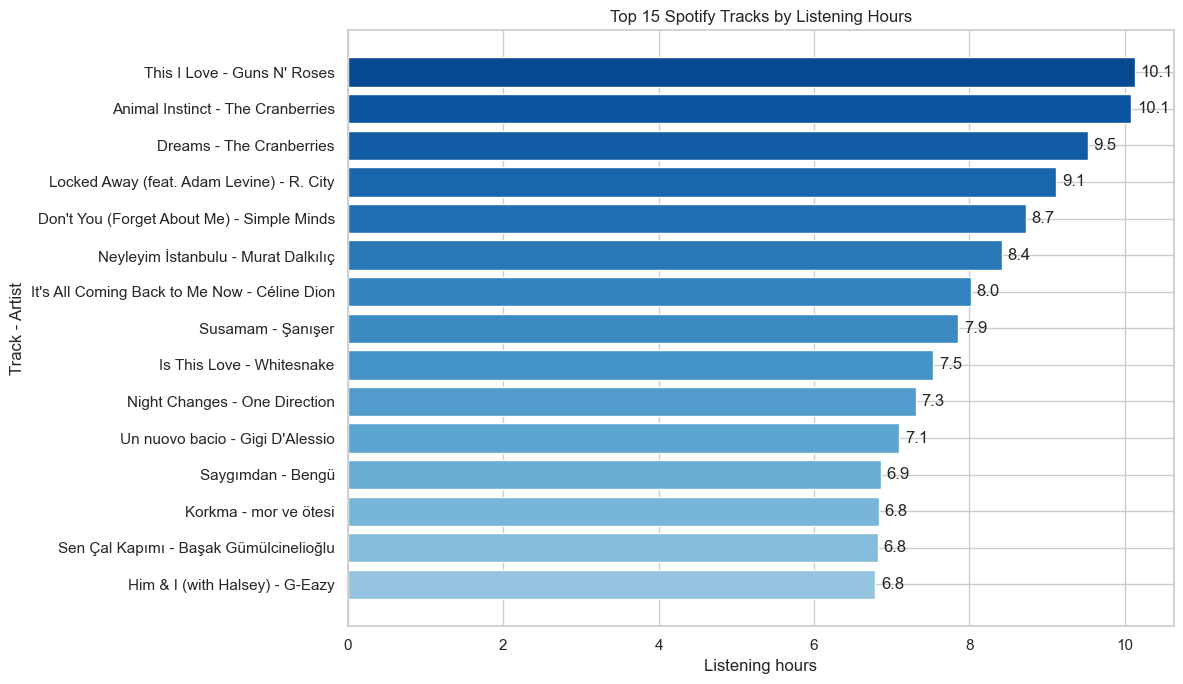

In [ ]:
# top 15 tracks by total listening hours. This can help us understand which specific songs are most listened to and if there are any standout tracks in the listening history.

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(spotify_top_tracks.index,spotify_top_tracks.values,color=plt.cm.Blues(np.linspace(0.4, 0.9, len(spotify_top_tracks))))

ax.set_title("Top 15 Spotify Tracks by Listening Hours")
ax.set_xlabel("Listening hours")
ax.set_ylabel("Track - Artist")
ax.bar_label(bars, fmt="%.1f", padding=4)
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_top_15_tracks_by_hours.png", dpi=300)
plt.show()


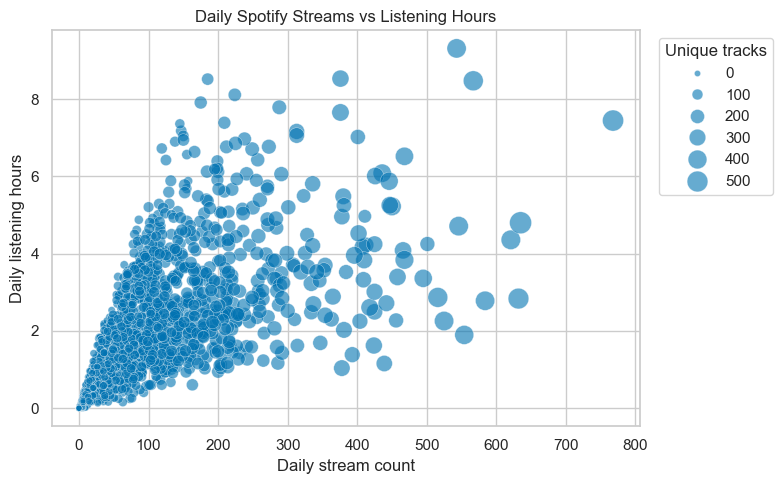

In [ ]:
# Relationship between daily stream count and daily listening hours.
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=spotify_daily,x="spotify_daily_stream_count",y="spotify_daily_hours",size="spotify_daily_unique_tracks",sizes=(20, 250),alpha=0.6,ax=ax)

ax.set_title("Daily Spotify Streams vs Listening Hours")
ax.set_xlabel("Daily stream count")
ax.set_ylabel("Daily listening hours")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Unique tracks")
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_daily_streams_vs_hours.png", dpi=300)
plt.show()


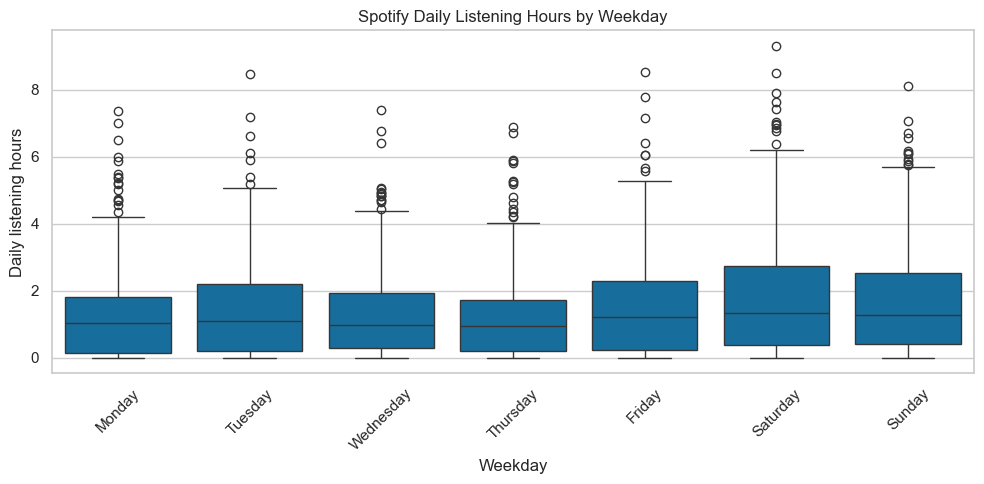

In [ ]:
# Weekday pattern.
spotify_daily["weekday"] = spotify_daily["fine_date"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=spotify_daily,x="weekday",y="spotify_daily_hours",order=weekday_order,ax=ax)

ax.set_title("Spotify Daily Listening Hours by Weekday")
ax.set_xlabel("Weekday")
ax.set_ylabel("Daily listening hours")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_daily_hours_by_weekday_boxplot.png", dpi=300)
plt.show()


In [ ]:
# Hour-of-day pattern in Istanbul time.
spotify_data["hour_istanbul"] = spotify_data["fine_time_start_dt"].dt.hour

spotify_hourly = (spotify_data.groupby("hour_istanbul").agg(spotify_hourly_hours=("hours_played", "sum"),spotify_hourly_stream_count=("fine_record_id", "count")).reset_index())

print("Spotify hourly sample:")
print(spotify_hourly.head())


Spotify hourly sample:
   hour_istanbul  spotify_hourly_hours  spotify_hourly_stream_count
0              0            199.432765                        16646
1              1             98.971464                         9501
2              2             32.030671                         3869
3              3              8.633036                          692
4              4              1.508800                          101


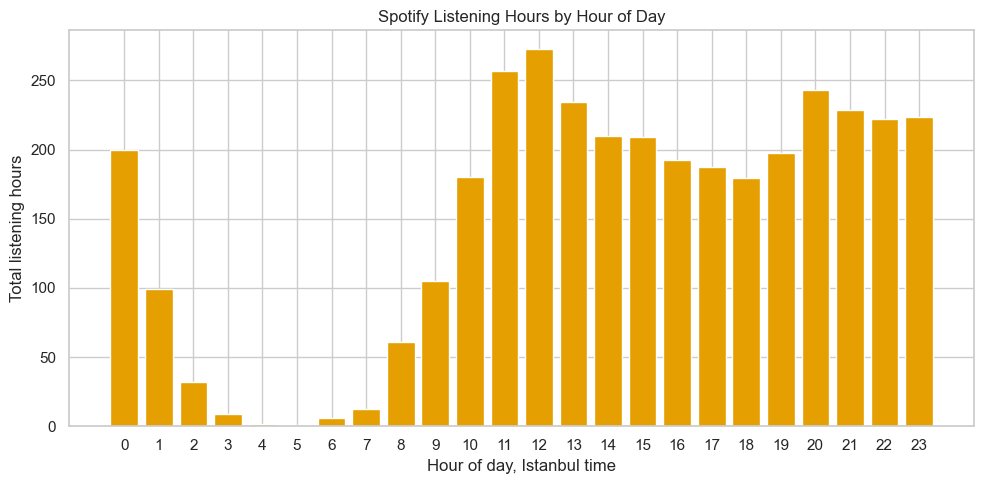

In [ ]:
# listenig hours by hour of day. This can help us understand if there are specific times of day when listening is more common, which can be useful for understanding daily routines and habits related to music consumption.
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(spotify_hourly["hour_istanbul"],spotify_hourly["spotify_hourly_hours"],color="#E69F00")

ax.set_title("Spotify Listening Hours by Hour of Day")
ax.set_xlabel("Hour of day, Istanbul time")
ax.set_ylabel("Total listening hours")
ax.set_xticks(range(0, 24))
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_listening_hours_by_hour.png", dpi=300)
plt.show()


In [39]:
# After-9:30 PM analysis for later hypothesis testing.
spotify_data["minute_of_day"] = (
    spotify_data["fine_time_start_dt"].dt.hour * 60 +
    spotify_data["fine_time_start_dt"].dt.minute
)

spotify_data["is_after_2130"] = (
    (spotify_data["minute_of_day"] >= (21 * 60 + 30)) |
    (spotify_data["minute_of_day"] < (5 * 60))
)

spotify_after_2130_daily = (
    spotify_data[spotify_data["is_after_2130"]]
    .groupby("fine_date")
    .agg(
        spotify_after_2130_hours=("hours_played", "sum"),
        spotify_after_2130_stream_count=("fine_record_id", "count")
    )
    .reset_index()
)

spotify_daily = spotify_daily.merge(spotify_after_2130_daily, on="fine_date", how="left")

spotify_daily["spotify_after_2130_hours"] = spotify_daily["spotify_after_2130_hours"].fillna(0)
spotify_daily["spotify_after_2130_stream_count"] = spotify_daily["spotify_after_2130_stream_count"].fillna(0).astype(int)

spotify_daily["spotify_after_2130_hour_share"] = (
    spotify_daily["spotify_after_2130_hours"] /
    spotify_daily["spotify_daily_hours"].replace(0, np.nan)
).fillna(0)

print("Spotify after-9:30 PM daily sample:")
print(spotify_daily[[
    "fine_date",
    "spotify_daily_hours",
    "spotify_after_2130_hours",
    "spotify_after_2130_stream_count",
    "spotify_after_2130_hour_share"
]].head())


Spotify after-9:30 PM daily sample:
   fine_date  spotify_daily_hours  spotify_after_2130_hours  \
0 2019-07-27             0.314114                  0.000000   
1 2019-07-28             0.861175                  0.000000   
2 2019-07-29             1.745592                  1.109861   
3 2019-07-30             0.530142                  0.530142   
4 2019-07-31             0.653267                  0.000000   

   spotify_after_2130_stream_count  spotify_after_2130_hour_share  
0                                0                       0.000000  
1                                0                       0.000000  
2                               24                       0.635808  
3                               20                       1.000000  
4                                0                       0.000000  


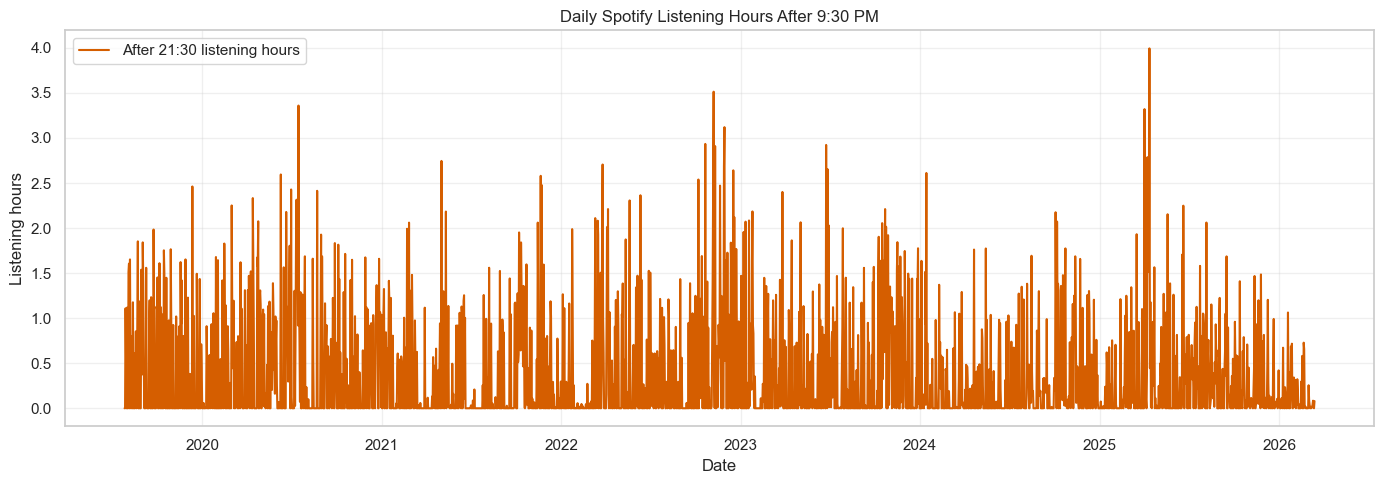

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    spotify_daily["fine_date"],
    spotify_daily["spotify_after_2130_hours"],
    color="#D55E00",
    linewidth=1.5,
    label="After 21:30 listening hours"
)

ax.set_title("Daily Spotify Listening Hours After 9:30 PM")
ax.set_xlabel("Date")
ax.set_ylabel("Listening hours")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(spotify_image_dir / "spotify_daily_after_2130_hours.png", dpi=300)
plt.show()


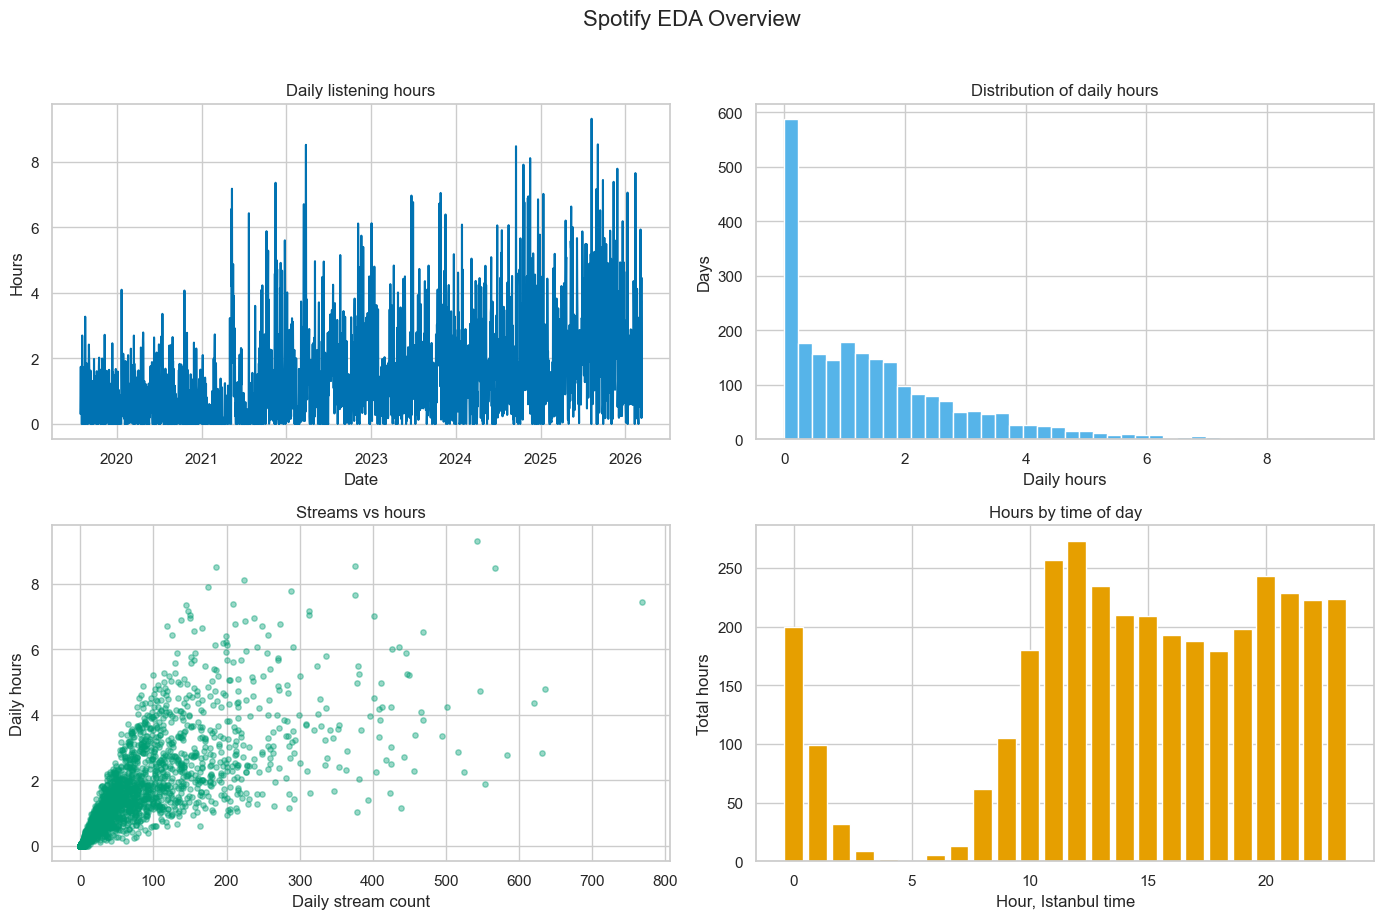

In [42]:
# 2x2 overview plot, similar to the recitation multi-panel style.
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

axes[0].plot(spotify_daily["fine_date"], spotify_daily["spotify_daily_hours"], color="#0072B2")
axes[0].set_title("Daily listening hours")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Hours")

axes[1].hist(spotify_daily["spotify_daily_hours"], bins=40, color="#56B4E9", edgecolor="white")
axes[1].set_title("Distribution of daily hours")
axes[1].set_xlabel("Daily hours")
axes[1].set_ylabel("Days")

axes[2].scatter(
    spotify_daily["spotify_daily_stream_count"],
    spotify_daily["spotify_daily_hours"],
    alpha=0.4,
    s=15,
    color="#009E73"
)
axes[2].set_title("Streams vs hours")
axes[2].set_xlabel("Daily stream count")
axes[2].set_ylabel("Daily hours")

axes[3].bar(spotify_hourly["hour_istanbul"], spotify_hourly["spotify_hourly_hours"], color="#E69F00")
axes[3].set_title("Hours by time of day")
axes[3].set_xlabel("Hour, Istanbul time")
axes[3].set_ylabel("Total hours")

fig.suptitle("Spotify EDA Overview", fontsize=16, y=1.02)
fig.tight_layout()

plt.savefig(spotify_image_dir / "spotify_eda_overview_panel.png", dpi=300)
plt.show()
